# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Muhammad Surya Ibrahim
- **Email:** ibrahimbtaz@gmail.com
- **ID Dicoding:** ibrahimibtaz

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang menyumbang total pendapatan (revenue) tertinggi dan terendah sepanjang tahun 2018, sehingga perusahaan dapat memfokuskan strategi pemasaran pada kategori yang paling menguntungkan?
- **Pertanyaan 2:** Berapa persentase pesanan yang mengalami keterlambatan pengiriman (waktu pengiriman aktual melebihi estimasi) selama kuartal ke-4 tahun 2017, sebagai bahan evaluasi kinerja mitra logistik?
- ...

## Import Semua Packages/Library yang Digunakan

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [61]:
# Memuat dataset yang dibutuhkan
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")

order_items_prod = pd.merge(order_items_df, products_df, on='product_id', how='left')
order_items_prod_eng = pd.merge(order_items_prod, category_translation_df, on='product_category_name', how='left')
all_data = pd.merge(orders_df, order_items_prod_eng, on='order_id', how='left')

# Menampilkan 5 baris pertama dari dataframe orders untuk memastikan data berhasil dimuat
all_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


**Insight:** (Opsional)
- xxx
- xxx

### Assessing Data

#### Identifying ... problem

In [62]:
# Cek tipe data
all_data.info()
# Cek missing value
all_data.isna().sum()
# Cek duplikat
all_data.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   order_item_id                  112650 non-null  float64
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price                         

np.int64(0)

**Steps to Take:**
- Kolom tanggal seperti order_purchase_timestamp, order_delivered_customer_date, dll masih berupa object (string), seharusnya datetime.
- Terdapat nilai kosong (NaN) pada kolom product_category_name_english atau tanggal pengiriman.

**Insight:** (Opsional)
- xxx
- xxx

### Cleaning Data

#### Fixing ... problem

In [63]:
# 1. Mengubah tipe data kolom waktu dari object menjadi datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for column in datetime_columns:
    all_data[column] = pd.to_datetime(all_data[column])

# 2. Menangani Missing Value
# Menghapus baris yang tidak memiliki tanggal pengiriman, kategori produk, atau harga
all_data.dropna(subset=['order_delivered_customer_date', 'product_category_name_english', 'price'], inplace=True)

# Memastikan data sudah bersih
print("=== Cek Missing Value Setelah Dibersihkan ===")
print(all_data.isna().sum())

print("\n=== Cek Tipe Data Setelah Dibersihkan ===")
all_data.info()

=== Cek Missing Value Setelah Dibersihkan ===
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
order_item_id                     0
product_id                        0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
product_category_name             0
product_name_lenght               0
product_description_lenght        0
product_photos_qty                0
product_weight_g                  1
product_length_cm                 1
product_height_cm                 1
product_width_cm                  1
product_category_name_english     0
dtype: int64

=== Cek Tipe Data Setelah Dibersihkan ===
<class 'pandas.core.frame.DataFrame'>
Index: 108637 entries, 0 to 1134

**Insight:** (Opsional)
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore ...

In [64]:
# === EDA Pertanyaan 1 ===
# Filter data khusus untuk transaksi di tahun 2018
sales_2018 = all_data[all_data['order_purchase_timestamp'].dt.year == 2018]

# Kelompokkan berdasarkan nama kategori produk bahasa inggris, lalu jumlahkan harganya (revenue)
revenue_per_category_2018 = sales_2018.groupby('product_category_name_english')['price'].sum().reset_index()

# Urutkan dari pendapatan tertinggi ke terendah
revenue_sorted = revenue_per_category_2018.sort_values(by='price', ascending=False)

print("=== 5 Kategori dengan Pendapatan Tertinggi (2018) ===")
print(revenue_sorted.head())

print("\n=== 5 Kategori dengan Pendapatan Terendah (2018) ===")
print(revenue_sorted.tail())

# === EDA Pertanyaan 2 ===
# Filter data untuk Q4 tahun 2017
q4_2017_data = all_data[(all_data['order_purchase_timestamp'] >= '2017-10-01') &
                        (all_data['order_purchase_timestamp'] <= '2017-12-31')].copy()

# PENTING: Hapus duplikat order_id agar kita menghitung jumlah pesanan, bukan jumlah barang
q4_2017_data = q4_2017_data.drop_duplicates(subset='order_id')

# Buat kolom baru bernama 'is_late'
q4_2017_data['is_late'] = q4_2017_data['order_delivered_customer_date'] > q4_2017_data['order_estimated_delivery_date']

# Hitung total pesanan dan total pesanan yang terlambat
total_orders = len(q4_2017_data)
late_orders = q4_2017_data['is_late'].sum()

# Hitung persentase
late_percentage = (late_orders / total_orders) * 100

print(f"Total Pesanan Unik di Q4 2017: {total_orders}")
print(f"Pesanan Terlambat di Q4 2017: {late_orders}")
print(f"Persentase Keterlambatan: {late_percentage:.2f}%")

=== 5 Kategori dengan Pendapatan Tertinggi (2018) ===
   product_category_name_english      price
43                 health_beauty  755754.49
69                 watches_gifts  687577.20
7                 bed_bath_table  532358.85
64                sports_leisure  517166.26
15         computers_accessories  496158.31

=== 5 Kategori dengan Pendapatan Terendah (2018) ===
   product_category_name_english   price
27        fashio_female_clothing  616.66
32                 fashion_sport  369.50
29     fashion_childrens_clothes  169.97
46                home_comfort_2  151.09
11             cds_dvds_musicals   65.00
Total Pesanan Unik di Q4 2017: 16930
Pesanan Terlambat di Q4 2017: 1702
Persentase Keterlambatan: 10.05%


**Insight:** (Opsional)
- xxx
- xxx

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_8651/2523173744.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=revenue_sorted.head(5), palette=colors_top, ax=ax[0])
/tmp/ipykernel_8651/2523173744.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=revenue_sorted.tail(5).sort_values(by="price", ascending=True), palette=colors_bottom, ax=ax[1])


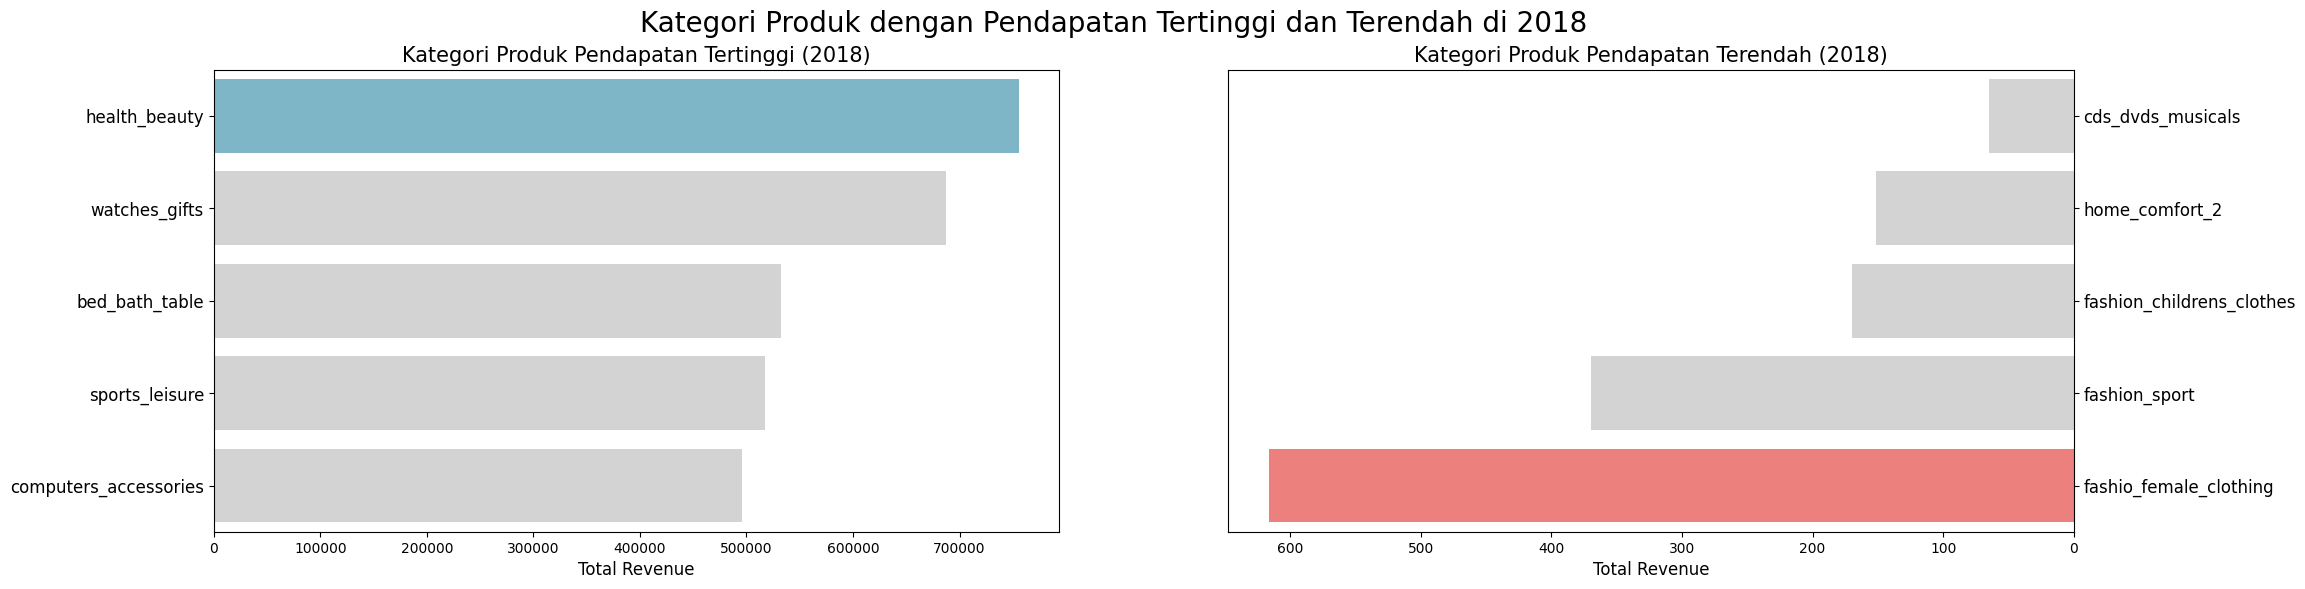

In [65]:
# === Visualisasi Pertanyaan 1 ===
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

# Menentukan warna (Highlight biru untuk tertinggi, merah untuk terendah, sisanya abu-abu)
colors_top = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
colors_bottom = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#ff6f69"]

# Membuat bar chart untuk 5 kategori tertinggi
sns.barplot(x="price", y="product_category_name_english", data=revenue_sorted.head(5), palette=colors_top, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Total Revenue", fontsize=12)
ax[0].set_title("Kategori Produk Pendapatan Tertinggi (2018)", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

# Membuat bar chart untuk 5 kategori terendah
sns.barplot(x="price", y="product_category_name_english", data=revenue_sorted.tail(5).sort_values(by="price", ascending=True), palette=colors_bottom, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Revenue", fontsize=12)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Kategori Produk Pendapatan Terendah (2018)", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Kategori Produk dengan Pendapatan Tertinggi dan Terendah di 2018", fontsize=20)
plt.show()

### Pertanyaan 2:

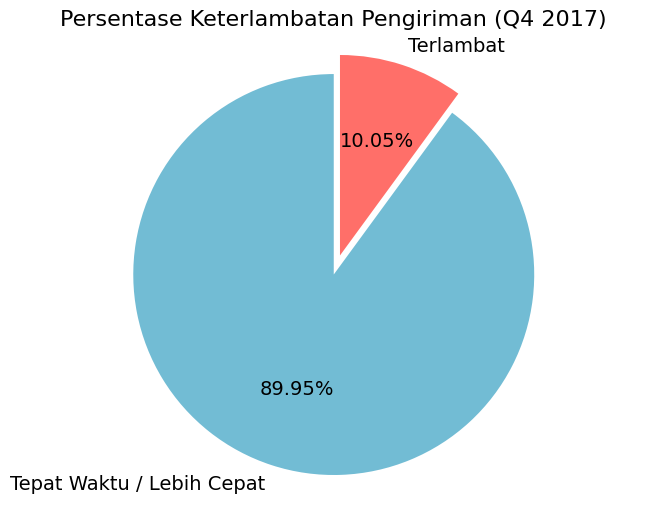

In [66]:
# === Visualisasi Pertanyaan 2 ===
labels = ['Tepat Waktu / Lebih Cepat', 'Terlambat']
sizes = [total_orders - late_orders, late_orders]
colors = ['#72BCD4', '#ff6f69']
explode = (0, 0.1) # Memisahkan potongan pie untuk bagian yang terlambat

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%',
        shadow=False, startangle=90, textprops={'fontsize': 14})
ax.axis('equal') # Memastikan pie chart berbentuk lingkaran sempurna

plt.title("Persentase Keterlambatan Pengiriman (Q4 2017)", fontsize=16)
plt.show()

**Insight:** (Opsional)
- xxx
- xxx

## Analisis Lanjutan (Opsional)

In [58]:
# Buat data RFM
rfm_df = all_data.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max", # Mengambil tanggal order terakhir
    "order_id": "nunique",             # Menghitung jumlah order
    "price": "sum"                     # Menghitung total spend
})

rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# Menghitung Recency (Kapan terakhir belanja dihitung dari transaksi terakhir di database)
recent_date = all_data["order_purchase_timestamp"].max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)

# Hapus kolom max_order_timestamp karena tidak dipakai lagi
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df.head()
# Anda juga bisa menambahkan visualisasi bar chart top 5 customer by Recency, Frequency, dan Monetary di sini.

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,287
1,000161a058600d5901f007fab4c27140,1,54.90,409
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99,547
3,0002414f95344307404f0ace7a26f1d5,1,149.90,378
4,000379cdec625522490c315e70c7a9fb,1,93.00,149


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori produk health_beauty merupakan penyumbang pendapatan terbesar di tahun 2018 (lebih dari 700.000 BRL), sedangkan kategori cds_dvds_musicals adalah yang terendah. Kategori kesehatan, kecantikan, jam tangan, dan perlengkapan rumah tangga mendominasi pasar.
- **Conclusion pertanyaan 2:** Kinerja pengiriman pada Q4 2017 menunjukkan bahwa terdapat 10,05% pesanan yang mengalami keterlambatan dari estimasi waktu yang diberikan kepada pelanggan.
- ...

**Rekomendasi Action Item:**
- Perusahaan harus mengalokasikan porsi anggaran marketing yang lebih besar untuk mempromosikan kategori unggulan seperti Health & Beauty dan Watches & Gifts. Sebaliknya, pertimbangkan untuk mengurangi stok atau melakukan promosi cuci gudang pada kategori bawah seperti CDs/DVDs/Musicals.
- Persentase keterlambatan 10,05% cukup signifikan. Perusahaan perlu melakukan investigasi lebih lanjut dengan mitra ekspedisi (carrier) yang bertugas pada Q4 2017 dan memperketat Service Level Agreement (SLA) pengiriman agar tingkat keterlambatan bisa ditekan di bawah angka 5% pada kuartal sibuk berikutnya.

In [59]:
all_data.to_csv("main_data.csv", index=False)